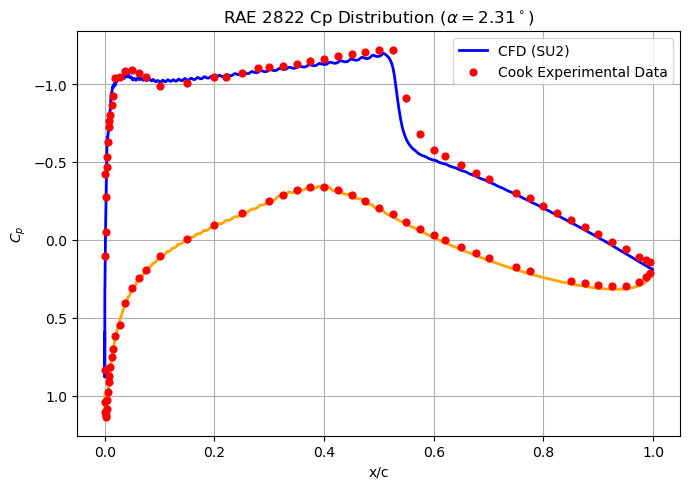

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# load data
# -------------------------

cook = pd.read_csv("Data/Cook.csv")
cfd = pd.read_csv("Data/cp a=231.csv")

# -------------------------
# rename columns
# -------------------------

cfd = cfd.rename(columns={
    "Pressure_Coefficient": "Cp",
    "Points:0": "x",
    "Points:1": "y",
    "Points:2": "z"
})

# experimental data
x_exp = cook["x/c"]
cp_exp = cook["Cp"]

# -------------------------
# hard-coded split
# -------------------------
# python indexing:
# rows 2 to 501   -> upper surface
# rows 502 onward -> lower surface

upper = cfd.iloc[3:502].copy()
lower = cfd.iloc[502:999].copy()

# sort each surface so the lines are smooth
upper = upper.sort_values("x", ascending=False)   # TE -> LE
lower = lower.sort_values("x", ascending=True)    # LE -> TE

# -------------------------
# plot
# -------------------------

plt.figure(figsize=(7,5))

plt.plot(upper["x"], upper["Cp"],
         color="blue", linewidth=2, label="CFD (SU2)")
plt.plot(lower["x"], lower["Cp"],
         color="orange", linewidth=2)

plt.scatter(x_exp, cp_exp,
            color="red", s=24, label="Cook Experimental Data", zorder=3)

plt.xlabel("x/c")
plt.ylabel("$C_p$")
plt.title("RAE 2822 Cp Distribution ($\\alpha = 2.31^\\circ$)")
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("Outputs/cp_comparison.pdf")
plt.show()

alpha = 0:
    Cl: 0.2854462567
    Cd: 0.009454651387
    Cm: 0.08772991074

alpha = 1:
    Cl: 0.4707784783
    Cd: 0.00988135004
    Cm: 0.08945258356

alpha = 2.31:
    Cl: 0.72695431
    Cd: 0.01319445754
    Cm: 0.0905937131

alpha = 4:
    Cl: 0.955890234
    Cd: 0.0358717192
    Cm: 0.0935404574

alpha = 5:
    Cl: 0.9631991031
    Cd: 0.05151892909
    Cm: 0.0842658794

cl = 0.85:
    Cl: 0.8495836082
    Cd: 0.01997346109
    Cm: 0.09305426148
    AOA: 2.989114798

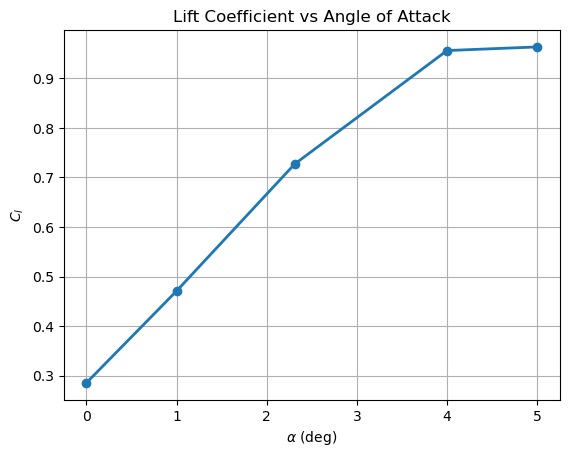

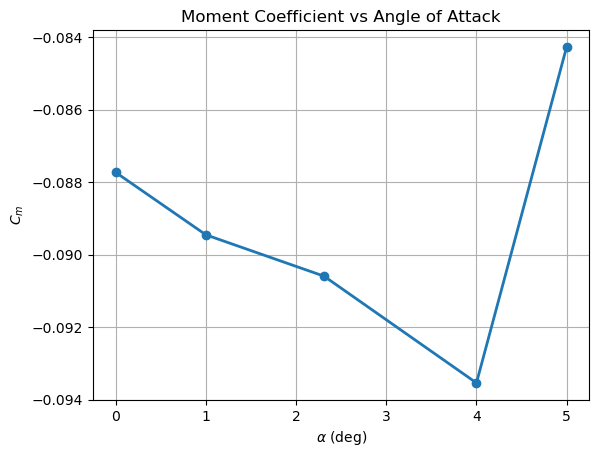

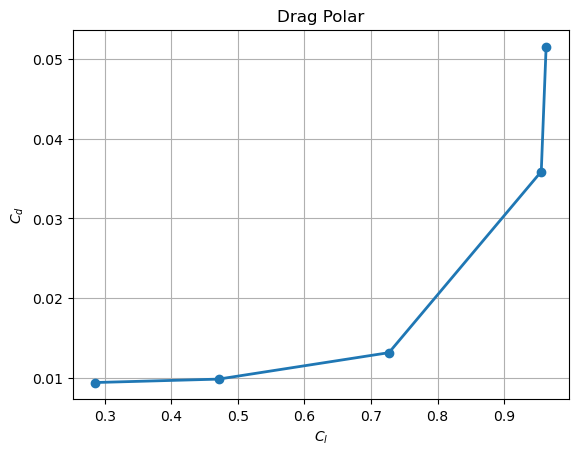

Lift curve slope (CFD) = 9.677109058252144 1/rad


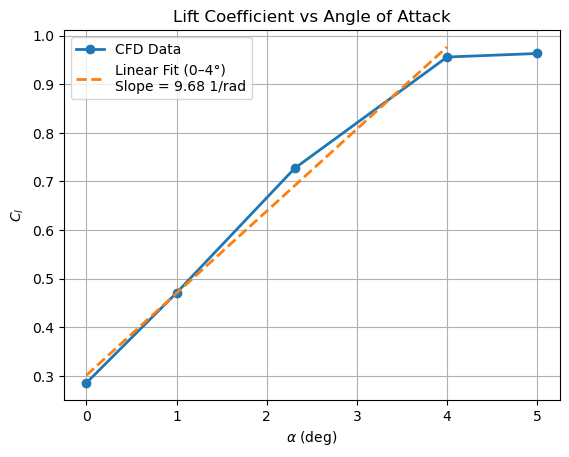

Theoretical slope = 9.179049804223684 1/rad
Percent difference = 5.426043704428765 %


In [35]:
import numpy as np

# -------------------------
# data from SU2 history.csv
# -------------------------

alpha = np.array([0, 1, 2.31, 4, 5])

Cl = np.array([
0.2854462567,
0.4707784783,
0.72695431,
0.955890234,
0.9631991031
])

Cd = np.array([
0.009454651387,
0.00988135004,
0.01319445754,
0.0358717192,
0.05151892909
])

Cm = -np.array([   # flip SU2 sign convention
0.08772991074,
0.08945258356,
0.0905937131,
0.0935404574,
0.0842658794
])

# -------------------------
# Plot Cl vs alpha
# -------------------------

plt.figure()
plt.plot(alpha, Cl, 'o-', linewidth=2)
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel(r'$C_l$')
plt.title("Lift Coefficient vs Angle of Attack")
plt.grid(True)
plt.savefig("Outputs/cl_vs_alpha.pdf")
plt.show()

# -------------------------
# Plot Cm vs alpha
# -------------------------

plt.figure()
plt.plot(alpha, Cm, 'o-', linewidth=2)
plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel(r'$C_m$')
plt.title("Moment Coefficient vs Angle of Attack")
plt.grid(True)
plt.savefig("Outputs/cm_vs_alpha.pdf")
plt.show()

# -------------------------
# Plot Cd vs Cl (drag polar)
# -------------------------

plt.figure()
plt.plot(Cl, Cd, 'o-', linewidth=2)
plt.xlabel(r'$C_l$')
plt.ylabel(r'$C_d$')
plt.title("Drag Polar")
plt.grid(True)
plt.savefig("Outputs/cd_vs_cl.pdf")
plt.show()

# -------------------------
# Lift curve slope
# use linear region 0°–4°
# -------------------------

mask = alpha <= 4
alpha_linear = alpha[mask]
Cl_linear = Cl[mask]

# convert alpha to radians
alpha_rad = np.deg2rad(alpha_linear)

# linear fit
slope, intercept = np.polyfit(alpha_rad, Cl_linear, 1)

print("Lift curve slope (CFD) =", slope, "1/rad")

# -------------------------
# Plot Cl vs alpha
# -------------------------

plt.figure()

# CFD data with connecting line
plt.plot(alpha, Cl, 'o-', linewidth=2, label="CFD Data")

# regression line (linear region)
alpha_fit = np.linspace(min(alpha_linear), max(alpha_linear), 100)
alpha_fit_rad = np.deg2rad(alpha_fit)

Cl_fit = slope*alpha_fit_rad + intercept

plt.plot(alpha_fit, Cl_fit, '--', linewidth=2,
         label=f"Linear Fit (0–4°)\nSlope = {slope:.2f} 1/rad")

plt.xlabel(r'$\alpha$ (deg)')
plt.ylabel(r'$C_l$')
plt.title("Lift Coefficient vs Angle of Attack")
plt.grid(True)
plt.legend()

plt.savefig("Outputs/cl_vs_alpha.pdf")
plt.show()

# -------------------------
# theoretical value
# -------------------------

M = 0.729
beta = np.sqrt(1 - M**2)

Cl_alpha_theory = 2*np.pi / beta

print("Theoretical slope =", Cl_alpha_theory, "1/rad")

percent_diff = abs((slope - Cl_alpha_theory) / Cl_alpha_theory)*100
print("Percent difference =", percent_diff, "%")

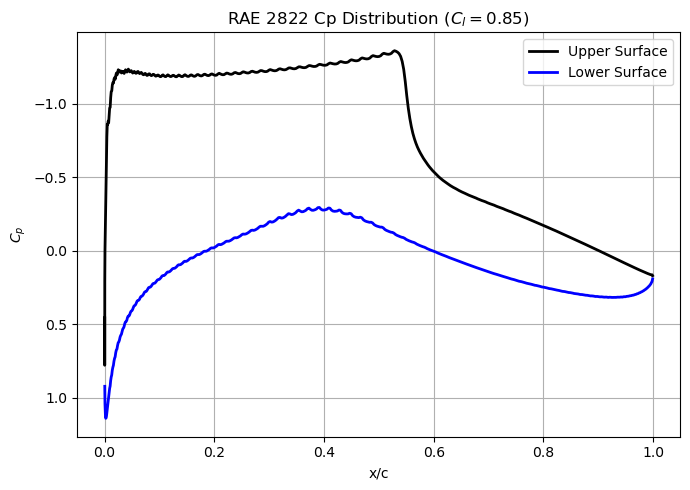

In [32]:
# -------------------------
# load CFD data
# -------------------------

cfd = pd.read_csv("Data/cp cl=085.csv")

# rename columns
cfd = cfd.rename(columns={
    "Pressure_Coefficient": "Cp",
    "Points:0": "x",
    "Points:1": "y",
    "Points:2": "z"
})

# -------------------------
# split upper / lower surfaces
# -------------------------

upper = cfd.iloc[3:502].copy()
lower = cfd.iloc[502:999].copy()

# sort for smooth plotting
upper = upper.sort_values("x", ascending=False)
lower = lower.sort_values("x", ascending=True)

# -------------------------
# plot
# -------------------------

plt.figure(figsize=(7,5))

plt.plot(upper["x"], upper["Cp"],
         color="black", linewidth=2, label="Upper Surface")

plt.plot(lower["x"], lower["Cp"],
         color="blue", linewidth=2, label="Lower Surface")

plt.xlabel("x/c")
plt.ylabel("$C_p$")
plt.title("RAE 2822 Cp Distribution ($C_l = 0.85$)")
plt.legend()
plt.grid(True)

# aerodynamic Cp convention
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("Outputs/design_cp_distribution.pdf")
plt.show()